# Bloch-wave dynamicality analyser

This notebook reproduces the XDS-based orientation reconstruction used by the original HTML prototype and extends it with an optional thickness-aware Bloch propagation mode.


## 1. Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
        if (candidate / 'src').exists():
            PROJECT_ROOT = candidate
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.parsers import parse_composition, parse_gxparm, parse_integrate_hkl, load_optional_xds_inp
from src.pipeline import AnalysisConfig, run_analysis
from src.visualization import plot_detector_frame, plot_frame_summary, plot_thickness_scan
from src.wilson import wilson_calibrate

plt.rcParams['figure.dpi'] = 120


## 2. Input file paths

In [2]:
gxparm_path = PROJECT_ROOT / 'data' / 'GXPARM.XDS'
integrate_path = PROJECT_ROOT / 'data' / 'INTEGRATE.HKL'
xdsinp_path = PROJECT_ROOT / 'data' / 'XDS.INP'  # optional


## 3. Composition entry

In [3]:
composition_text = '24 Si, 48 O'
composition = parse_composition(composition_text)
composition


CompositionResult(entries=(CompositionEntry(count=24.0, element='Si', forward_scattering_factor=5.31), CompositionEntry(count=48.0, element='O', forward_scattering_factor=2.26)), sum_fj2=921.8711999999998)

## 4. Parameter setup

In [4]:
mode = 'thickness'  # 'proxy' or 'thickness'
dmin_angstrom = 0.6
dmax_angstrom = 50.0
excitation_tolerance_invA = 1.5e-3

# Single thickness example:
single_thickness_nm = 100.0

# Thickness scan example:
thickness_scan_nm = np.arange(20.0, 301.0, 10.0)

thickness_parameter = thickness_scan_nm if mode == 'thickness' else None
config = AnalysisConfig(
    dmin_angstrom=dmin_angstrom,
    dmax_angstrom=dmax_angstrom,
    excitation_tolerance_invA=excitation_tolerance_invA,
    mode=mode,
    thickness_nm=thickness_parameter,
)
config


AnalysisConfig(dmin_angstrom=0.6, dmax_angstrom=50.0, excitation_tolerance_invA=0.0015, mode='thickness', thickness_nm=array([ 20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.,
       130., 140., 150., 160., 170., 180., 190., 200., 210., 220., 230.,
       240., 250., 260., 270., 280., 290., 300.]), zone_axis_limit=5, filter_untrusted=False)

## 5. Parsing input files

In [5]:
gxparm = parse_gxparm(gxparm_path)
integrate = parse_integrate_hkl(integrate_path)
xds_input = load_optional_xds_inp(xdsinp_path if xdsinp_path.exists() else None)

print(gxparm)
print(f'Observations: {integrate.observations.shape[0]:,}')
print(f'Estimated frames: {integrate.estimated_n_frames}')
print(xds_input)


GXPARMData(phi0_deg=-45.0, dphi_deg=0.12, rotation_axis=array([ 0.15390299,  0.98808496, -0.00141   ]), wavelength_angstrom=0.01969, space_group=221, unit_cell=UnitCell(a=11.9093, b=11.9093, c=11.9093, alpha=90.0, beta=90.0, gamma=90.0), real_space_reference=array([[ 7.404853, -4.951198,  7.904694],
       [ 7.410264,  9.252246, -1.146436],
       [-5.664497,  5.631338,  8.833566]]), reciprocal_reference=array([[ 0.05220921,  0.05224737, -0.03993853],
       [-0.03490928,  0.06523458,  0.03970474],
       [ 0.05573343, -0.00808314,  0.06228261]]), detector_nx=512, detector_ny=512, pixel_x_mm=0.055, pixel_y_mm=0.055, orgx_px=243.985016, orgy_px=249.383392, distance_mm=444.567657)
Observations: 14,363
Estimated frames: 753
XDSInputData(untrusted_rectangles=[(256.0, 259.0, 1.0, 512.0), (1.0, 511.0, 255.0, 259.0)], data_range=(1, 757))


## 6. Wilson calibration

In [6]:
wilson = wilson_calibrate(integrate.observations, composition.sum_fj2)
print(f'Wilson-like K: {wilson.scale_factor:.6f}')
print(f'Median |Fg| fallback: {wilson.median_amplitude:.3f}')
wilson.merged_table.head()


Wilson-like K: 0.129790
Median |Fg| fallback: 14.055


,symmetry_key,merged_I,n_observations,n_weighted,Fg_abs
0,"(19, 2, 0)",16.469675,11,11,11.264749
1,"(19, 2, 1)",10.565724,23,23,9.022537
2,"(19, 2, 2)",4.230628,12,12,5.709282
3,"(19, 3, 2)",22.431004,25,25,13.146295
4,"(19, 4, 2)",8.883379,28,28,8.273097


## 7. Running the pipeline

In [7]:
result = run_analysis(
    gxparm=gxparm,
    integrate=integrate,
    composition=composition,
    xds_input=xds_input,
    config=config,
)

result.frame_summary.head()


,frame,frame_number,phi_deg,zone_axis,zone_axis_angle_deg,n_excited,S_2beam,S_MB,mean_N_eff,max_N_eff,eigenvalue_spread_invA,frame_thickness_mean_std,frame_thickness_mean_cv,frame_thickness_mean_normalized_range
0,0,1,-45.00,[5 2 1],5.739649,51,6.828998,22.747544,4.717180,9.903901,0.004348,0.009939,0.782867,2.934768
1,1,2,-44.88,[5 2 1],5.737626,45,5.761329,16.950187,3.962922,9.984552,0.003806,0.011989,0.808114,2.905672
2,2,3,-44.76,[5 1 1],5.728461,49,4.223302,15.047062,4.431546,12.568454,0.004027,0.009631,0.770318,2.815418
3,3,4,-44.64,[5 1 1],5.633845,38,3.478022,9.056825,3.814928,7.781439,0.003534,0.012507,0.720947,2.500549
4,4,5,-44.52,[4 1 1],5.530839,36,2.530919,5.218929,3.535572,8.662828,0.003298,0.011221,0.698156,2.441091


## 8. Plotting frame summaries

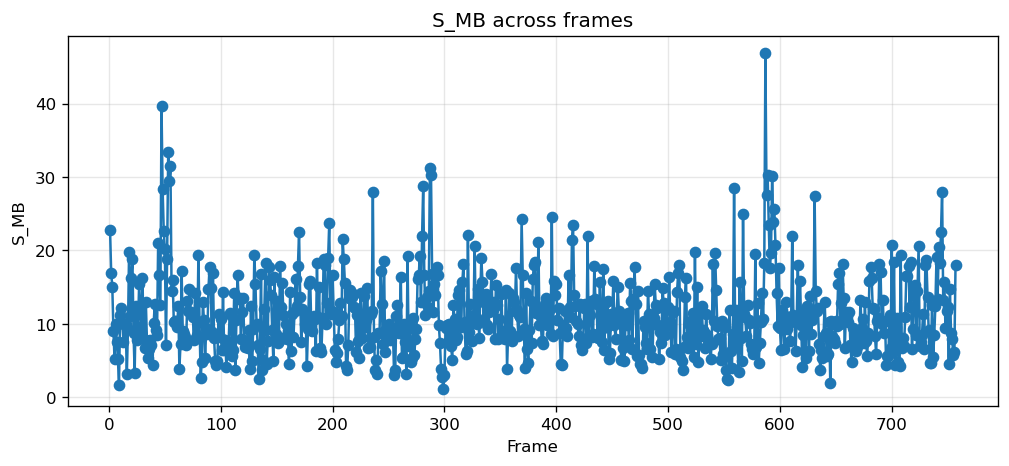

,frame,frame_number,phi_deg,zone_axis,zone_axis_angle_deg,n_excited,S_2beam,S_MB,mean_N_eff,max_N_eff,eigenvalue_spread_invA,frame_thickness_mean_std,frame_thickness_mean_cv,frame_thickness_mean_normalized_range
586,586,587,25.32,[1 -1 3],0.456693,53,9.915493,46.905058,5.330260,13.624306,0.005335,0.011021,0.785074,2.903172
46,46,47,-39.48,[4 1 1],0.491302,55,8.766922,39.639366,5.610518,10.799812,0.005212,0.010213,0.764228,2.911131
52,52,53,-38.76,[4 1 1],0.230268,45,7.824198,33.417687,4.326655,10.523613,0.004572,0.010975,0.796036,3.004377
54,54,55,-38.52,[4 1 1],0.469721,51,8.874625,31.449739,4.424509,9.039889,0.005165,0.009845,0.781507,2.926546
286,286,287,-10.68,[5 0 4],0.370886,58,8.550220,31.188593,5.271640,12.483033,0.004791,0.010411,0.784970,2.834040


In [8]:
ax = plot_frame_summary(result.frame_summary, y='S_MB', title='S_MB across frames')
plt.show()

result.frame_summary.sort_values('S_MB', ascending=False).head()


## 9. Plotting one selected frame on the detector

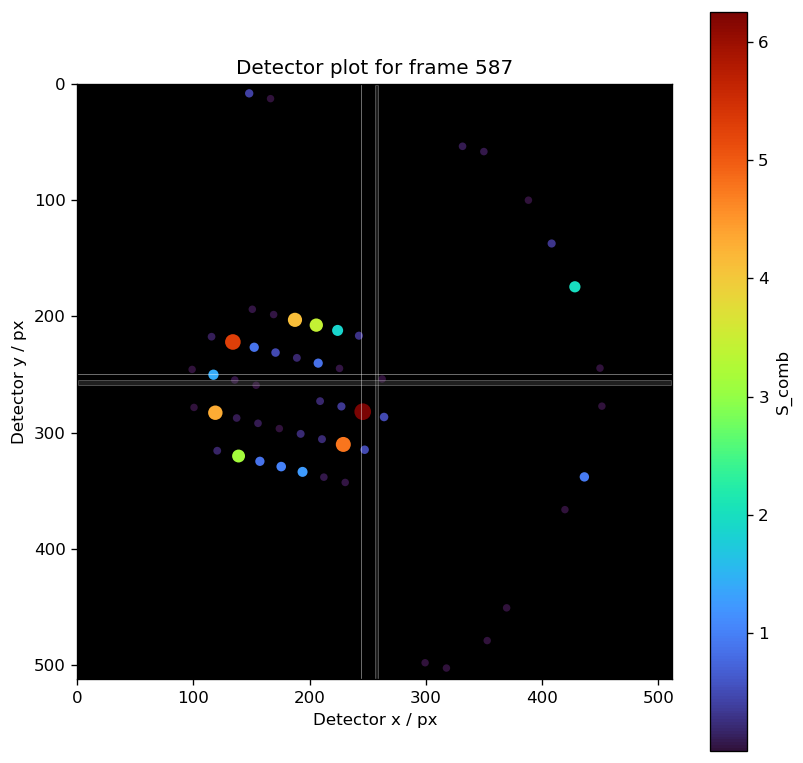

,h,k,l,gx_ref,gy_ref,gz_ref,q_invA,d_angstrom,reflection_index,Fg_abs,...,frame,frame_number,phi_deg,sg_invA,x_px,y_px,in_untrusted_region,d_2beam,N_eff,S_comb
25320,-1,2,1,0.012347,0.205083,-0.009617,0.205679,4.861934,15187,48.355784,...,586,587,25.32,-8.739447e-07,245.615532,282.077925,False,0.999976,6.254753,6.254605
25297,-6,-6,0,-0.626739,-0.181952,-0.285902,0.712495,1.403519,8934,88.322014,...,586,587,25.32,1.569875e-04,133.912326,222.092436,False,0.813361,6.518186,5.301641
25313,-3,3,2,-0.079763,0.379841,-0.066884,0.393846,2.539062,12787,162.289534,...,586,587,25.32,-1.144113e-04,228.901834,310.225829,False,0.965160,4.945959,4.773640
25288,-9,-3,2,-0.706502,0.197889,-0.352786,0.814103,1.228346,5881,18.309937,...,586,587,25.32,4.257616e-05,118.824147,282.939791,False,0.718018,5.999406,4.307684
25314,-2,-5,-1,-0.325717,-0.296059,-0.133334,0.459913,2.174323,13685,55.501485,...,586,587,25.32,7.936779e-05,187.321179,203.043122,False,0.870681,4.719885,4.109512
25318,-1,-4,-1,-0.221260,-0.265734,-0.085683,0.356247,2.807039,14951,84.003020,...,586,587,25.32,5.320318e-05,205.666212,207.592025,False,0.971690,3.525503,3.425696
25289,-9,0,3,-0.589699,0.433298,-0.314753,0.796593,1.255346,5987,46.429206,...,586,587,25.32,1.543650e-04,138.801706,320.186325,False,0.554674,5.661915,3.140516
25337,14,3,-4,1.047425,-0.451845,0.506888,1.248278,0.801103,30834,17.003853,...,586,587,25.32,-5.911001e-05,428.101563,174.625000,False,0.532562,3.755013,1.999779
25322,0,-3,-1,-0.116804,-0.235408,-0.038033,0.265531,3.766037,16219,70.539787,...,586,587,25.32,3.046932e-04,224.010661,212.140783,False,0.424604,4.418513,1.876117
25290,-8,-5,1,-0.718849,-0.007194,-0.343169,0.796593,1.255346,6812,46.621206,...,586,587,25.32,1.822779e-04,117.194479,250.241345,False,0.473874,2.989634,1.416710


In [9]:
selected_frame = int(result.frame_summary.sort_values('S_MB', ascending=False).iloc[0]['frame'])
frame_table = result.frame_table(selected_frame)
ax = plot_detector_frame(
    frame_table,
    gxparm,
    rectangles=(xds_input.untrusted_rectangles if xds_input is not None else None),
    title=f'Detector plot for frame {selected_frame + 1}',
)
plt.show()

frame_table.sort_values('S_comb', ascending=False).head(10)


## 10. Plotting thickness sensitivity for selected reflections

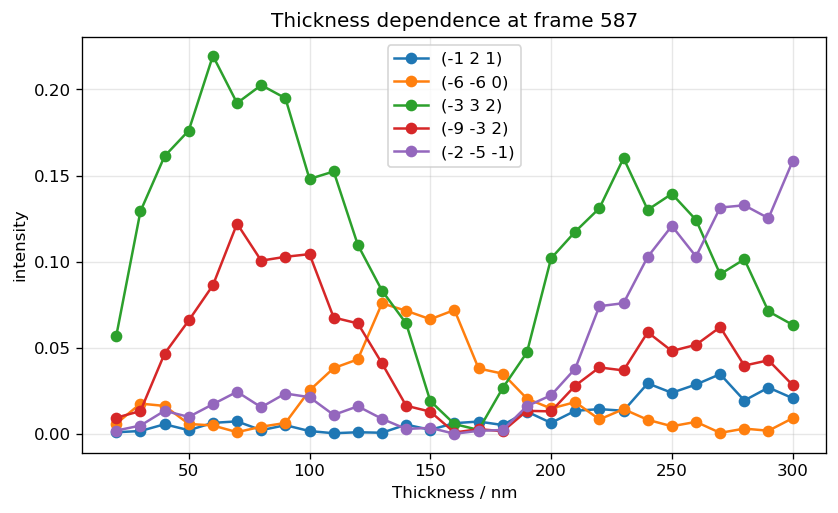

,frame,frame_number,h,k,l,thickness_std,thickness_cv,thickness_max_min_ratio,thickness_normalized_range
18441,424,425,1,-16,-4,0.000607,1.543133,679.276389,7.409736
30850,713,714,6,13,5,0.004300,1.540875,278.978700,7.362446
13540,312,313,8,4,-9,0.014481,1.748774,226.545825,7.324587
17798,409,410,6,-12,-7,0.006763,1.462054,249.697846,7.076360
16660,384,385,-11,-2,9,0.027624,1.795219,6467.648721,6.931156
17685,407,408,-2,9,3,0.003019,1.406867,571.042724,6.795566
21173,489,490,-11,8,8,0.000690,1.387610,225.086160,6.778129
16883,388,389,12,11,-9,0.001425,1.402052,1587.300399,6.643541
30443,704,705,11,-9,-5,0.001395,1.223662,159.582552,6.629364
8212,188,189,-9,4,15,0.001913,1.274044,172.975440,6.624832


In [10]:
if result.thickness_long is not None and not result.thickness_long.empty:
    selected_reflections = [
        tuple(map(int, row))
        for row in frame_table.sort_values('S_comb', ascending=False)[['h', 'k', 'l']].head(5).itertuples(index=False, name=None)
    ]
    ax = plot_thickness_scan(
        result.thickness_long,
        frame=selected_frame,
        reflections=selected_reflections,
        metric='intensity',
        title=f'Thickness dependence at frame {selected_frame + 1}',
    )
    plt.show()
    if result.reflection_sensitivity is not None:
        display(result.reflection_sensitivity.sort_values('thickness_normalized_range', ascending=False).head(10))
else:
    print('Thickness mode was not enabled, so no thickness scan is available.')


## 11. Exporting results to CSV

In [ ]:
output_dir = PROJECT_ROOT / 'analysis_output'
output_dir.mkdir(exist_ok=True)

result.frame_summary.to_csv(output_dir / 'frame_summary.csv', index=False)
result.reflections_long.to_csv(output_dir / 'reflections_long.csv', index=False)
if result.thickness_long is not None:
    result.thickness_long.to_csv(output_dir / 'thickness_long.csv', index=False)
if result.reflection_sensitivity is not None:
    result.reflection_sensitivity.to_csv(output_dir / 'reflection_sensitivity.csv', index=False)

print(f'Wrote CSV files to: {output_dir.resolve()}')
